In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv(r"C:\Users\dparh\Documents\GitHub\goit-project-final\internet_service_churn.csv")

df.head(5)

df.drop(columns=['id'], inplace=True)

### Construct a Classification model

#### Handle Na values

In [41]:
df['contract_missing'] = df['reamining_contract'].isnull().astype(int)  # Added a new column to indicate whether a client has an active contract or not

df['reamining_contract'] = df['reamining_contract'].fillna(0)

In [45]:
df["download_avg"]=df["download_avg"].fillna(df["download_avg"].mean(), inplace=True)
df['upload_avg']=df['upload_avg'].fillna(df['upload_avg'].mean(), inplace=True)


C:\Users\dparh\AppData\Local\Temp\ipykernel_13544\278519878.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["download_avg"]=df["download_avg"].fillna(df["download_avg"].mean(), inplace=True)
C:\Users\dparh\AppData\Local\Temp\ipykernel_13544\278519878.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame o

In [46]:
df.isna().sum()

is_tv_subscriber               0
is_movie_package_subscriber    0
subscription_age               0
bill_avg                       0
reamining_contract             0
service_failure_count          0
download_avg                   0
upload_avg                     0
download_over_limit            0
churn                          0
contract_missing               0
dtype: int64

#### Train/test split

In [47]:
from sklearn.linear_model import LogisticRegression

X = df.drop('churn', axis=1)
y = df['churn']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# fit the data into model
model_logistic = LogisticRegression(
    max_iter=1000
)

model_logistic.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [56]:
# evaluate performance of Logistic Regression model
y_pred = model_logistic.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}%")
# classification report
print(classification_report(y_test, y_pred))
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.87%
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      6445
           1       0.86      0.91      0.89      8010

    accuracy                           0.87     14455
   macro avg       0.87      0.87      0.87     14455
weighted avg       0.87      0.87      0.87     14455

F1 Score: 0.89
[[5276 1169]
 [ 685 7325]]


<Axes: >

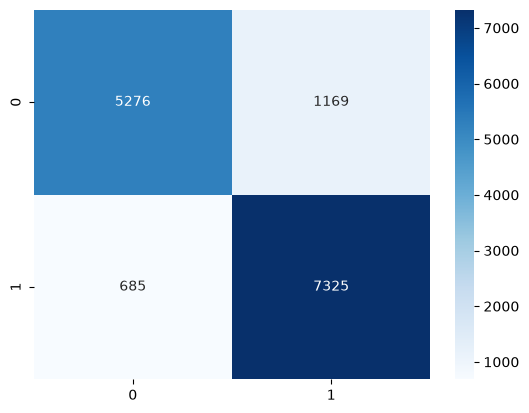

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [57]:
# cross validation
print(f"Cross-Validation Score: {cross_val_score(model_logistic, X, y, cv=5).mean():.2f}")

Cross-Validation Score: 0.85


### Create a random forest classifier based model

In [58]:
model_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=5    
)

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [59]:
# Evalute performance of random forest model
y_pred_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}%")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.93%
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      6445
           1       0.95      0.93      0.94      8010

    accuracy                           0.93     14455
   macro avg       0.93      0.93      0.93     14455
weighted avg       0.93      0.93      0.93     14455



<Axes: >

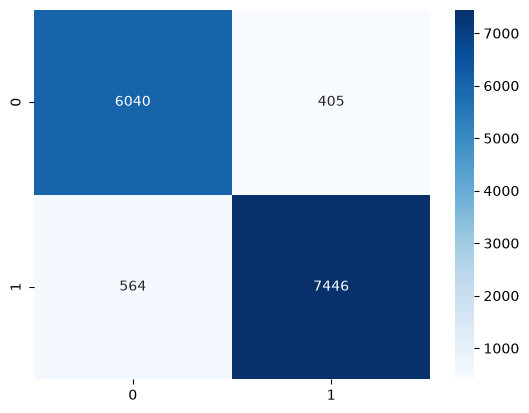

In [60]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')

In [61]:
print(cross_val_score(model_rf, X, y, cv=5).mean())

0.853709253660164


Models share similar cross validation scores, therefore the choice of the model is not relevant. Choose whatever you like

Now I will implement features scaling, since the numeric features have both continuous data and binary

In [64]:
from sklearn.preprocessing import StandardScaler

In [66]:
data_scaler = StandardScaler()
X_train_scaled = data_scaler.fit_transform(X_train)
X_test_scaled = data_scaler.transform(X_test)

model_logistic_scaled = LogisticRegression(max_iter=1000)
model_logistic_scaled.fit(X_train_scaled, y_train)

#quick evaluation
y_pred_scaled = model_logistic_scaled.predict(X_test_scaled)
print(classification_report(y_test, y_pred_scaled))
print(f"F1 Score: {f1_score(y_test, y_pred_scaled):.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_scaled):.2f}%")

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      6445
           1       0.86      0.91      0.89      8010

    accuracy                           0.87     14455
   macro avg       0.87      0.87      0.87     14455
weighted avg       0.87      0.87      0.87     14455

F1 Score: 0.89
Accuracy: 0.87%


In [67]:
print(cross_val_score(model_logistic_scaled, X_test_scaled, y_test, cv=5).mean())

0.8710480802490489


Scaling improved model's accuracy by about 2 percent

### The main model that will be used for this project will be Logistic Regression model, it will have the smallest chance of overfitting then the random forest regressor

In [ ]:
import os
import pickle

os.makedirs(r"C:\Users\dparh\Documents\GitHub\goit-project-final\Models", exist_ok=True)
model_path = r"C:\Users\dparh\Documents\GitHub\goit-project-final\Models\model_logistic.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model_logistic_scaled, f, protocol=pickle.HIGHEST_PROTOCOL)